In [1]:
!pip install textblob

Defaulting to user installation because normal site-packages is not writeable


# Google Play Store Analysis

## Project Objective

The objective of this project is to analyze Google Play Store app data to understand app categories, ratings, installations, pricing, content ratings, genres, and user reviews. The analysis also focuses on user sentiment to identify overall user feedback and app performance.

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Datasets

In [3]:
apps = pd.read_csv(
    r"D:\googleplaystore.csv.zip",
    compression="zip"
)

reviews = pd.read_csv(
    r"D:\17-googleplaystore_user_reviews.csv"
)

##  Dataset Overview

In [4]:
apps.shape

(10841, 13)

### Observation

The Apps dataset contains 10,841 rows and 13 columns.

In [5]:
reviews.shape

(64295, 5)

### Observation

The Reviews dataset contains user review records with information about the app, translated review, sentiment, sentiment polarity, and sentiment subjectivity.

## Display First 5 Records

In [6]:
apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


### Observation

The first five records provide an initial view of the Google Play Store apps and their attributes such as category, rating, reviews, installs, price, and content rating.

In [7]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


### Observation

The Reviews dataset contains user feedback for different applications. Each review can have a sentiment such as Positive, Negative, or Neutral along with polarity and subjectivity scores.

## Dataset Information

In [8]:
apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


### Observation

The Apps dataset contains 10,841 records and 13 columns. Most columns are stored as object data types, while Rating is stored as a float. The dataset contains missing values in Rating, Type, Content Rating, Current Ver, and Android Ver.

## Check Missing Values

In [9]:
apps.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

### Observation

This step identifies the number of missing values present in each column. Missing values need to be handled before performing further analysis.

In [10]:
reviews.isnull().sum()

App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

### Observation

The Reviews dataset contains missing values in some review-related columns. These missing values need to be considered during the cleaning process.

## Check Duplicate Records

In [11]:
apps.duplicated().sum()

np.int64(483)

### Observation

This identifies the number of completely duplicated records in the Apps dataset. Duplicate records can affect the accuracy of analysis, so they should be examined before removing them.

In [12]:
reviews.duplicated().sum()

np.int64(33616)

### Observation

Duplicate review records are identified to ensure that repeated records do not unnecessarily influence the analysis.

## Remove Duplicate Records from Apps Dataset

In [13]:
apps = apps.drop_duplicates()

In [14]:
apps.duplicated().sum()

np.int64(0)

In [15]:
apps.shape

(10358, 13)

### Observation

The Apps dataset initially contained 483 duplicate records. These duplicate records were removed to avoid repeated data affecting the analysis. After removing duplicates, the dataset contains 10,358 records.

### Handle Missing Values in Apps Dataset

In [16]:
apps.isnull().sum()

App                  0
Category             0
Rating            1465
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

### Observation

The Apps dataset contains missing values in Rating, Type, Content Rating, Current Ver, and Android Ver. Rating has the highest number of missing values, so it requires special attention during data cleaning.

###  Handle Missing Values in Rating

In [17]:
apps['Rating'] = apps['Rating'].fillna(apps['Rating'].median())

In [18]:
apps['Rating'].isnull().sum()

np.int64(0)

### Observation

The missing values in the Rating column were replaced with the median rating. Median was used because it is less affected by extreme values compared with the mean.

## Handle Remaining Missing Values

In [19]:
apps = apps.dropna(subset=['Type', 'Content Rating', 'Current Ver', 'Android Ver'])

In [20]:
apps.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [21]:
apps.shape

(10346, 13)

## Convert Data Types

In [22]:
apps[['Reviews', 'Installs', 'Price']].dtypes

Reviews     object
Installs    object
Price       object
dtype: object

### Observation

The Reviews, Installs, and Price columns are currently stored as object data types because they contain text characters such as commas, plus signs, and currency symbols. These columns need to be cleaned and converted into numeric data types for analysis.

## Convert Reviews to Numeric

In [23]:
apps['Reviews'] = pd.to_numeric(apps['Reviews'], errors='coerce')

In [24]:
apps['Reviews'].dtype

dtype('int64')

### Observation

The Reviews column was converted from object to a numeric data type, allowing us to perform calculations such as sum, mean, minimum, and maximum.

## Clean and Convert Installs

In [25]:
apps['Installs'] = apps['Installs'].str.replace(',', '', regex=False)
apps['Installs'] = apps['Installs'].str.replace('+', '', regex=False)
apps['Installs'] = pd.to_numeric(apps['Installs'], errors='coerce')

In [26]:
apps['Installs'].dtype

dtype('int64')

### Observation

The Installs column contained commas and plus signs, which prevented numerical analysis. These characters were removed and the column was converted into a numeric data type.

In [27]:
apps[['Reviews', 'Installs', 'Price']].dtypes

Reviews      int64
Installs     int64
Price       object
dtype: object

In [28]:
apps['Reviews'] = pd.to_numeric(apps['Reviews'], errors='coerce')

In [29]:
apps['Reviews'].dtype

dtype('int64')

In [30]:
apps['Installs'].dtype

dtype('int64')

In [31]:
apps['Installs'] = apps['Installs'].astype(str)
apps['Installs'] = apps['Installs'].str.replace(',', '', regex=False)
apps['Installs'] = apps['Installs'].str.replace('+', '', regex=False)
apps['Installs'] = pd.to_numeric(apps['Installs'], errors='coerce')

In [32]:
apps['Installs'].dtype

dtype('int64')

### Observation

The Installs column was converted into a numeric data type after removing commas and plus signs. This conversion allows the number of app installations to be used for numerical analysis and visualization.

## Clean and Convert Price

In [33]:
apps['Price'].unique()[:20]

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99'], dtype=object)

In [34]:
apps['Price'] = apps['Price'].str.replace('$', '', regex=False)
apps['Price'] = pd.to_numeric(apps['Price'], errors='coerce')

In [35]:
apps['Price'].dtype

dtype('float64')

### Observation

The Price column contained currency symbols such as '$', which prevented numerical calculations. The '$' symbol was removed and the column was converted into a numeric data type for further analysis.

In [36]:
apps[['Reviews', 'Installs', 'Price']].dtypes

Reviews       int64
Installs      int64
Price       float64
dtype: object

### Observation

The Price column contained currency symbols such as '$'. The '$' symbol was removed, and the column was converted into a numeric data type for further analysis.

## Check Data Types After Cleaning

In [37]:
apps.dtypes

App                object
Category           object
Rating            float64
Reviews             int64
Size               object
Installs            int64
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

### Observation

After data cleaning, the numerical columns such as Rating, Reviews, Installs, and Price are stored in appropriate numeric data types. The remaining categorical and descriptive columns are stored as object data types.

## Final Dataset Check

In [38]:
apps.shape

(10346, 13)

In [39]:
apps.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [40]:
apps.duplicated().sum()

np.int64(0)

### Observation

After removing duplicate records and handling missing values, the Apps dataset is clean and ready for exploratory data analysis. The important numerical columns have also been converted into appropriate numeric data types.

# Exploratory Data Analysis (EDA)

## App Distribution by Category

In [41]:
category_counts = apps['Category'].value_counts()

category_counts

Category
FAMILY                 1939
GAME                   1121
TOOLS                   841
BUSINESS                427
MEDICAL                 408
PRODUCTIVITY            407
PERSONALIZATION         386
LIFESTYLE               373
COMMUNICATION           366
FINANCE                 360
SPORTS                  351
PHOTOGRAPHY             322
HEALTH_AND_FITNESS      306
SOCIAL                  280
NEWS_AND_MAGAZINES      264
TRAVEL_AND_LOCAL        237
BOOKS_AND_REFERENCE     229
SHOPPING                224
DATING                  196
VIDEO_PLAYERS           175
MAPS_AND_NAVIGATION     137
EDUCATION               130
FOOD_AND_DRINK          124
ENTERTAINMENT           111
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       84
WEATHER                  82
HOUSE_AND_HOME           80
EVENTS                   64
ART_AND_DESIGN           64
PARENTING                60
COMICS                   60
BEAUTY                   53
Name: count, dtype: int64

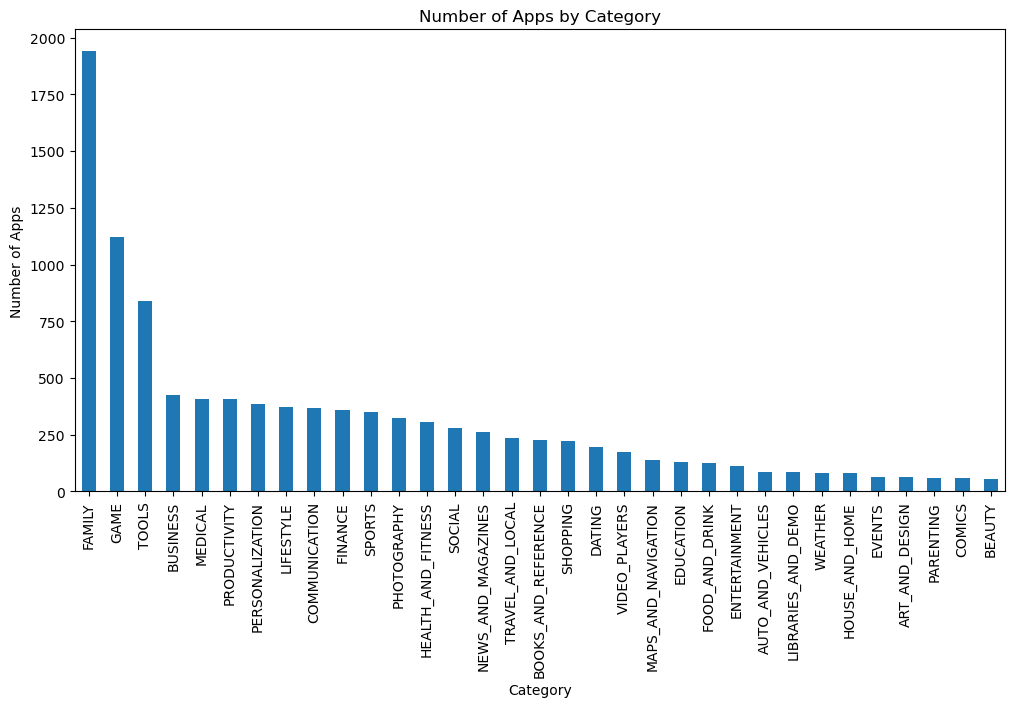

In [42]:
plt.figure(figsize=(12, 6))

category_counts.plot(kind='bar')

plt.title('Number of Apps by Category')
plt.xlabel('Category')
plt.ylabel('Number of Apps')
plt.xticks(rotation=90)

plt.show()

### Observation

The distribution shows that the number of apps varies across different categories. Some categories contain considerably more apps than others, indicating that certain app categories have a larger presence on the Google Play Store.

## Rating Analysis

In [43]:
apps['Rating'].mean()

np.float64(4.203769572781751)

In [44]:
apps['Rating'].min(), apps['Rating'].max()

(1.0, 5.0)

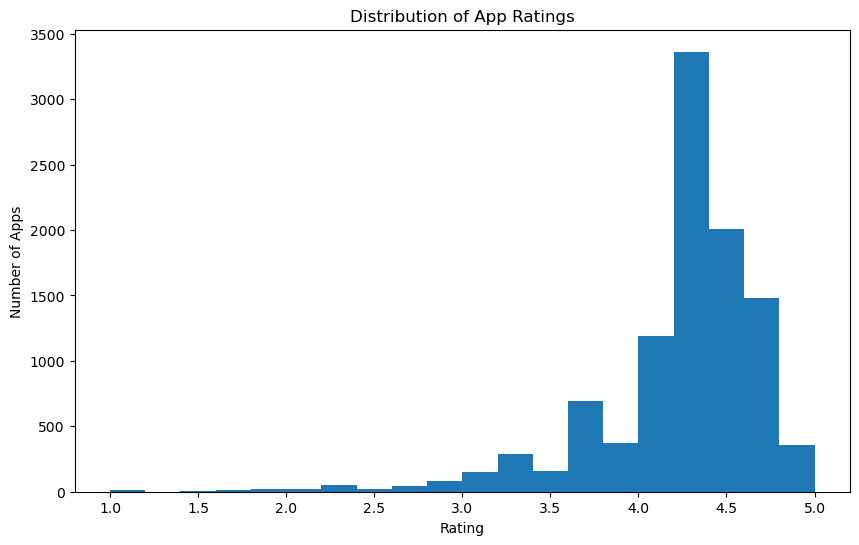

In [45]:
plt.figure(figsize=(10, 6))

plt.hist(apps['Rating'], bins=20)

plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Apps')

plt.show()

### Observation

The average app rating is approximately 4.20, indicating that apps in the dataset generally have good ratings. The ratings range from 1.0 to 5.0. The histogram shows that ratings are mostly concentrated toward the higher end of the scale, while relatively fewer apps have very low ratings.

## Most Reviewed Apps

In [46]:
top_reviewed_apps = (
    apps.groupby('App')['Reviews']
    .max()
    .sort_values(ascending=False)
    .head(10)

)

top_reviewed_apps

App
Facebook                                              78158306
WhatsApp Messenger                                    69119316
Instagram                                             66577446
Messenger – Text and Video Chat for Free              56646578
Clash of Clans                                        44893888
Clean Master- Space Cleaner & Antivirus               42916526
Subway Surfers                                        27725352
YouTube                                               25655305
Security Master - Antivirus, VPN, AppLock, Booster    24900999
Clash Royale                                          23136735
Name: Reviews, dtype: int64

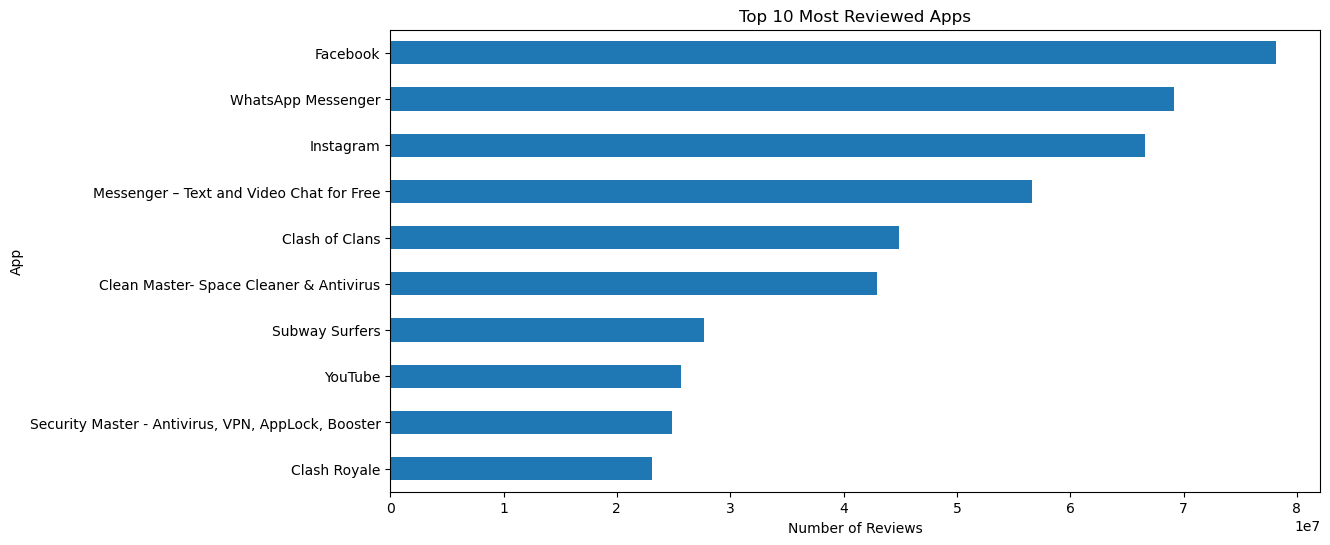

In [47]:
plt.figure(figsize=(12, 6))

top_reviewed_apps.sort_values().plot(kind='barh')

plt.title('Top 10 Most Reviewed Apps')
plt.xlabel('Number of Reviews')
plt.ylabel('App')

plt.show()

### Observation

The results show that some apps have a very high number of user reviews, indicating strong user engagement and popularity. Facebook, WhatsApp Messenger, and Instagram are among the apps with the highest review counts.

## Most Installed Apps

In [48]:
top_installed_apps = apps.sort_values(
    by='Installs',
    ascending=False
).head(10)

top_installed_apps[['App', 'Installs']]

,App,Installs
336,WhatsApp Messenger,1000000000
2554,Google+,1000000000
3127,Google Street View,1000000000
3816,Google News,1000000000
3223,Maps - Navigate & Explore,1000000000
2545,Instagram,1000000000
2544,Facebook,1000000000
865,Google Play Games,1000000000
3234,Google,1000000000
3736,Google News,1000000000


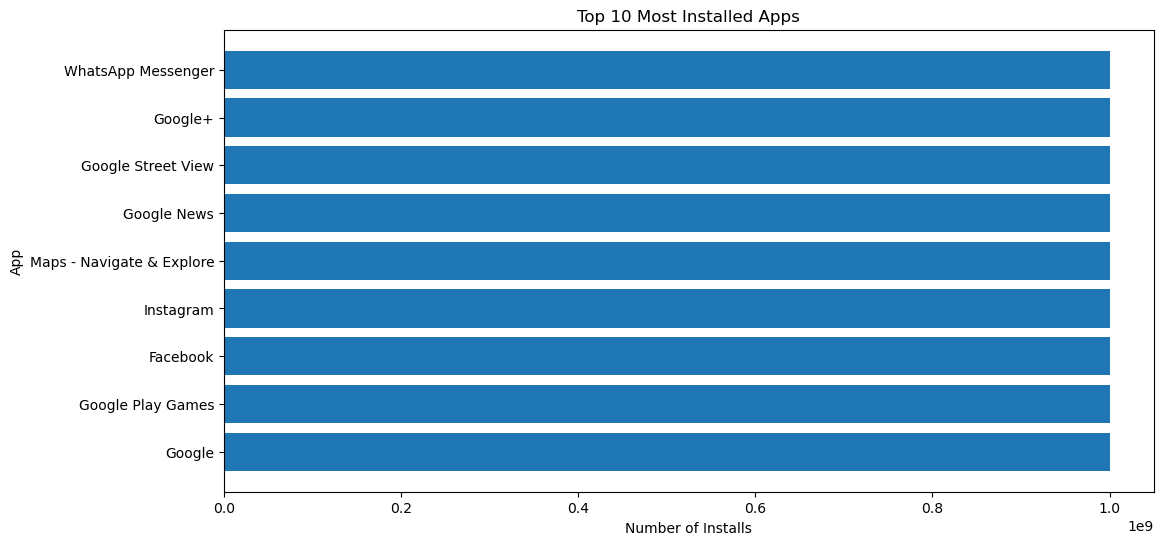

In [49]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_installed_apps['App'],
    top_installed_apps['Installs']
)

plt.title('Top 10 Most Installed Apps')
plt.xlabel('Number of Installs')
plt.ylabel('App')

plt.gca().invert_yaxis()

plt.show()

### Observation

Several apps in the dataset have reached 1 billion installs, showing very high popularity and widespread usage. WhatsApp Messenger, Instagram, Facebook, Google, Google News, Google Play Games, Google Street View, Google+, and Maps are among the apps with the highest recorded install counts.

## Free vs Paid Apps

In [50]:
type_counts = apps['Type'].value_counts()

type_counts

Type
Free    9584
Paid     762
Name: count, dtype: int64

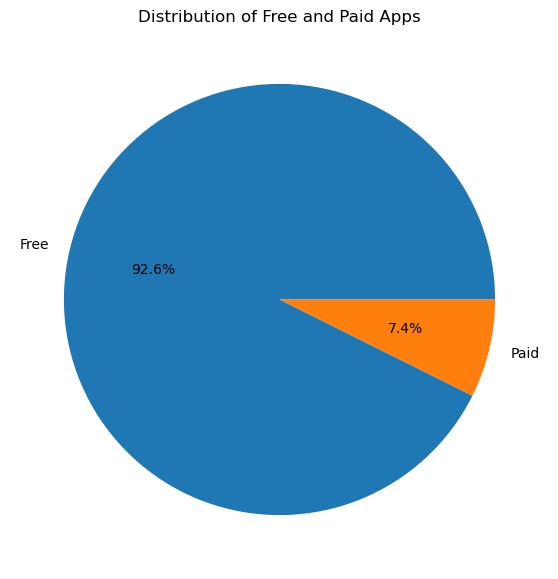

In [51]:
plt.figure(figsize=(7, 7))

plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%'
)

plt.title('Distribution of Free and Paid Apps')

plt.show()

### Observation

The dataset contains 9,584 free apps and 762 paid apps. Free apps make up approximately 92.6% of the dataset, while paid apps account for approximately 7.4%. This shows that free apps are much more common than paid apps on the Google Play Store.

##  Apps by Content Rating

In [52]:
content_rating_counts = apps['Content Rating'].value_counts()

content_rating_counts

Content Rating
Everyone           8372
Teen               1146
Mature 17+          447
Everyone 10+        376
Adults only 18+       3
Unrated               2
Name: count, dtype: int64

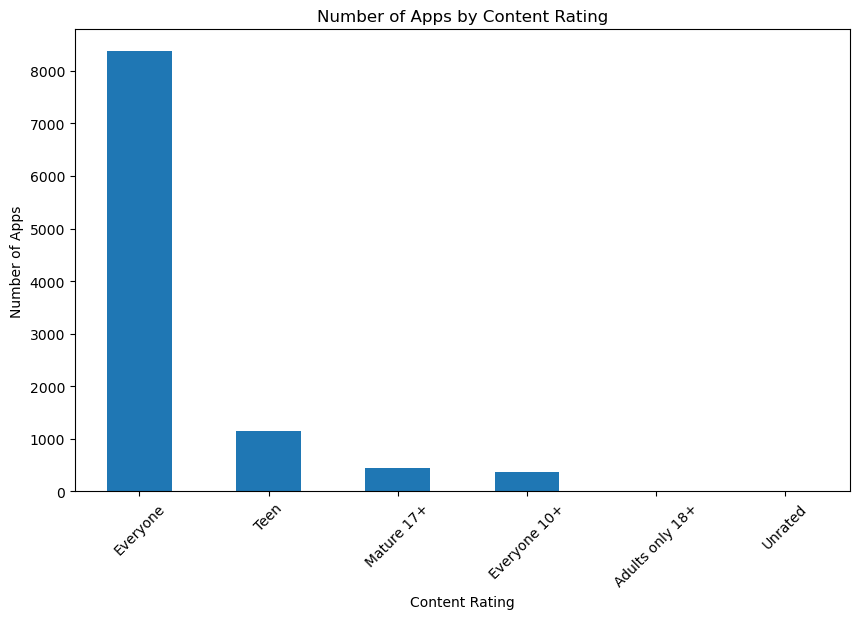

In [53]:
plt.figure(figsize=(10, 6))

content_rating_counts.plot(kind='bar')

plt.title('Number of Apps by Content Rating')
plt.xlabel('Content Rating')
plt.ylabel('Number of Apps')
plt.xticks(rotation=45)

plt.show()

### Observation

The Everyone content rating has the highest number of apps with 8,372 apps, followed by Teen with 1,146 apps. Mature 17+ and Everyone 10+ have fewer apps, while Adults only 18+ and Unrated have very few apps. This indicates that most apps in the dataset are suitable for a general audience.

## Apps by Genre

In [54]:
genre_counts = apps['Genres'].value_counts().head(10)

genre_counts

Genres
Tools              840
Entertainment      587
Education          526
Business           427
Medical            408
Productivity       407
Personalization    386
Lifestyle          372
Communication      366
Sports             364
Name: count, dtype: int64

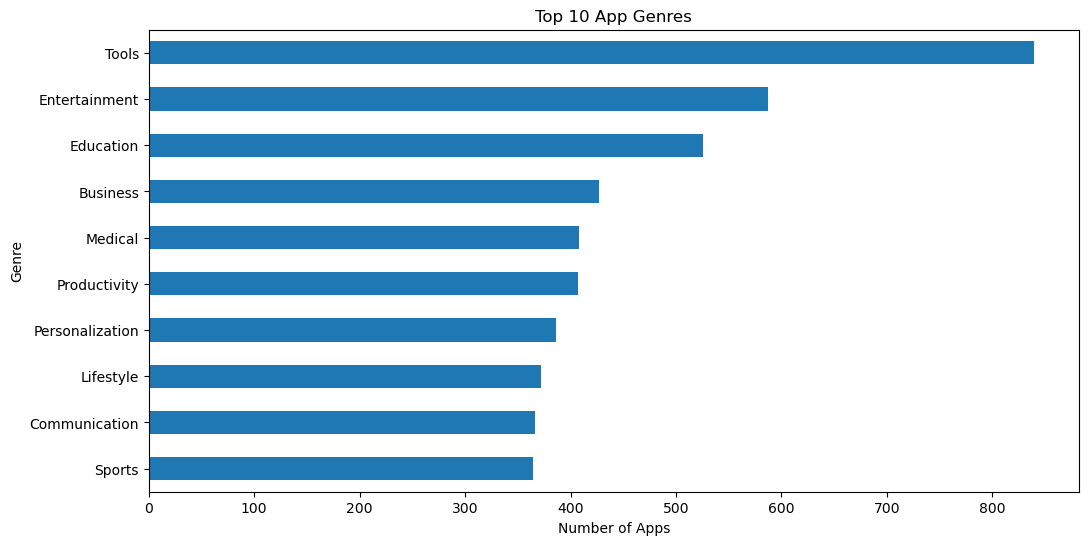

In [55]:
plt.figure(figsize=(12, 6))

genre_counts.sort_values().plot(kind='barh')

plt.title('Top 10 App Genres')
plt.xlabel('Number of Apps')
plt.ylabel('Genre')

plt.show()

### Observation

Among the top 10 app genres, Tools has the highest number of apps with 840 apps, followed by Entertainment with 587 apps and Education with 526 apps. Business and Medical also have a significant number of apps. Sports has the lowest count among the top 10 genres with 364 apps.

## Average Rating by Category

In [56]:
category_rating = apps.groupby('Category')['Rating'].mean().sort_values(ascending=False)

category_rating

Category
EVENTS                 4.395313
EDUCATION              4.375385
ART_AND_DESIGN         4.373437
BOOKS_AND_REFERENCE    4.336681
PERSONALIZATION        4.326425
PARENTING              4.300000
BEAUTY                 4.283019
GAME                   4.282070
HEALTH_AND_FITNESS     4.266993
SOCIAL                 4.260714
SHOPPING               4.256250
WEATHER                4.248780
SPORTS                 4.239031
PRODUCTIVITY           4.219410
MEDICAL                4.212990
LIBRARIES_AND_DEMO     4.208333
AUTO_AND_VEHICLES      4.205882
FAMILY                 4.203713
PHOTOGRAPHY            4.189441
HOUSE_AND_HOME         4.185000
FOOD_AND_DRINK         4.183871
COMMUNICATION          4.175410
BUSINESS               4.175176
NEWS_AND_MAGAZINES     4.160985
COMICS                 4.160000
FINANCE                4.148056
ENTERTAINMENT          4.136036
LIFESTYLE              4.133244
TRAVEL_AND_LOCAL       4.121941
VIDEO_PLAYERS          4.084000
TOOLS                  4.079667

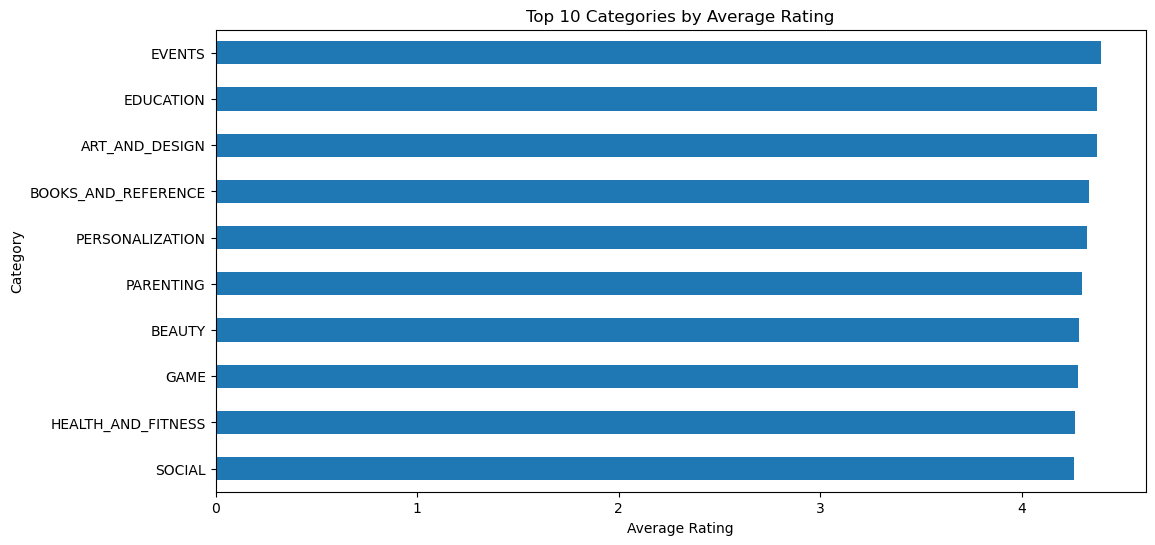

In [57]:
top_category_rating = category_rating.head(10)

plt.figure(figsize=(12, 6))

top_category_rating.sort_values().plot(kind='barh')

plt.title('Top 10 Categories by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Category')

plt.show()

### Observation

The EVENTS category has the highest average rating of approximately 4.40, followed by EDUCATION and ART_AND_DESIGN. Most categories have an average rating above 4.0, indicating generally positive user ratings across the categories. DATING has the lowest average rating at approximately 4.03.

## Average Rating by App Type

In [58]:
type_rating = apps.groupby('Type')['Rating'].mean()

type_rating

Type
Free    4.198560
Paid    4.269291
Name: Rating, dtype: float64

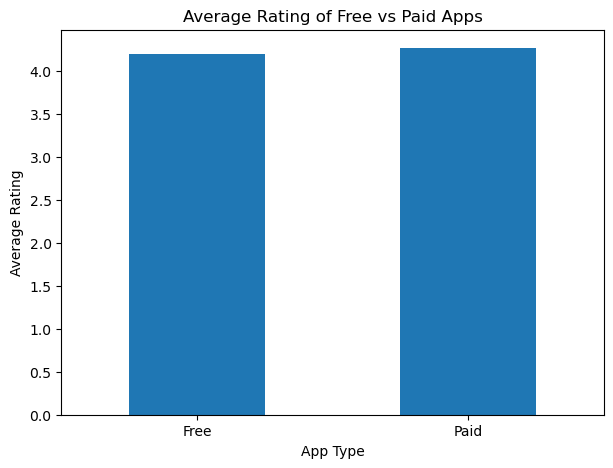

In [59]:
plt.figure(figsize=(7, 5))

type_rating.plot(kind='bar')

plt.title('Average Rating of Free vs Paid Apps')
plt.xlabel('App Type')
plt.ylabel('Average Rating')
plt.xticks(rotation=0)

plt.show()

### Observation

Paid apps have a slightly higher average rating of approximately 4.27 compared with free apps, which have an average rating of approximately 4.20. This indicates that paid apps receive slightly better ratings on average in this dataset.

## Price Analysis of Paid Apps

In [60]:
paid_apps = apps[apps['Type'] == 'Paid']

paid_apps[['App', 'Price']].head(10)

,App,Price
234,TurboScan: scan documents and receipts in PDF,4.99
235,Tiny Scanner Pro: PDF Doc Scan,4.99
427,Puffin Browser Pro,3.99
476,"Moco+ - Chat, Meet People",3.99
477,Calculator,6.99
478,Truth or Dare Pro,1.49
479,"Private Dating, Hide App- Blue for PrivacyHider",2.99
480,Ad Blocker for SayHi,3.99
481,AMBW Dating App: Asian Men Black Women Interra...,7.99
571,"Moco+ - Chat, Meet People",3.99


In [61]:
paid_apps['Price'].max()

400.0

In [62]:
paid_apps['Price'].min()

0.99

In [63]:
paid_apps['Price'].mean()

np.float64(14.005944881889764)

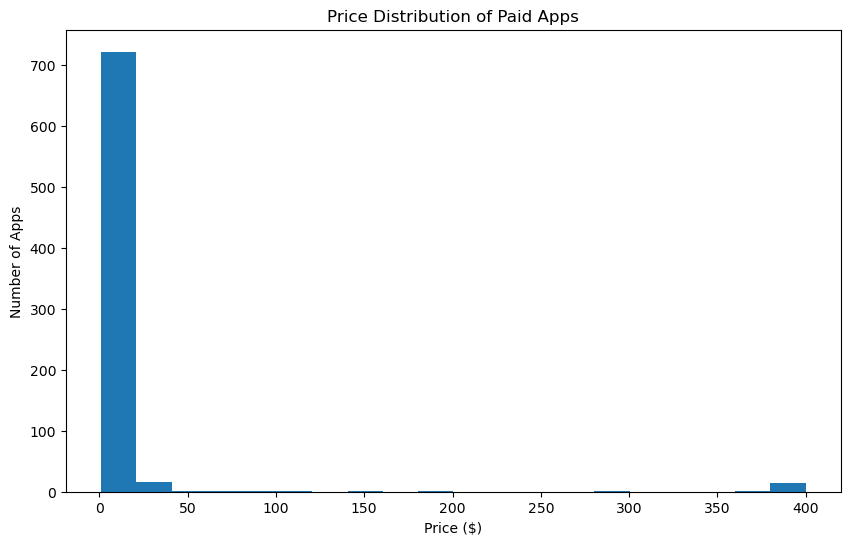

In [64]:
plt.figure(figsize=(10, 6))

plt.hist(paid_apps['Price'], bins=20)

plt.title('Price Distribution of Paid Apps')
plt.xlabel('Price ($)')
plt.ylabel('Number of Apps')

plt.show()

### Observation

The analysis shows that the maximum price of a paid app is $400, while the average price of paid apps is approximately $14.01. The price distribution indicates that most paid apps are available at relatively lower prices, while a small number of apps have much higher prices.

## Sentiment Analysis of User Reviews

In [65]:
sentiment_counts = reviews['Sentiment'].value_counts()

sentiment_counts

Sentiment
Positive    23998
Negative     8271
Neutral      5163
Name: count, dtype: int64

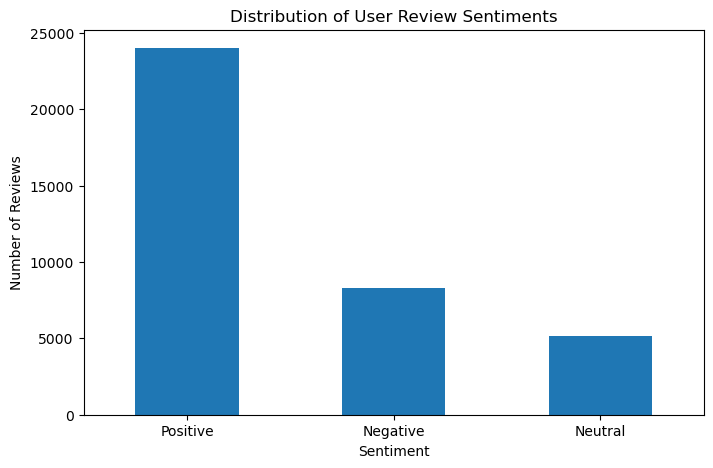

In [66]:
plt.figure(figsize=(8, 5))

sentiment_counts.plot(kind='bar')

plt.title('Distribution of User Review Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)

plt.show()

### Observation

The sentiment analysis shows that Positive reviews are the highest with 23,998 reviews, followed by Negative reviews with 8,271 and Neutral reviews with 5,163. This indicates that users generally have a positive opinion about the apps in the dataset.

## Average Sentiment Polarity

In [67]:
sentiment_polarity = reviews.groupby('Sentiment')['Sentiment_Polarity'].mean()

sentiment_polarity

Sentiment
Negative   -0.256173
Neutral     0.000000
Positive    0.372402
Name: Sentiment_Polarity, dtype: float64

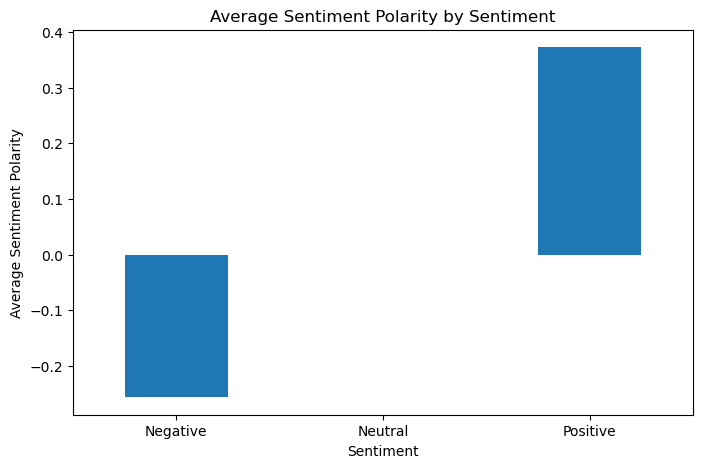

In [68]:
plt.figure(figsize=(8, 5))

sentiment_polarity.plot(kind='bar')

plt.title('Average Sentiment Polarity by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Sentiment Polarity')
plt.xticks(rotation=0)

plt.show()

### Observation

The average sentiment polarity for Positive reviews is approximately 0.37, indicating a positive opinion. Negative reviews have an average polarity of approximately -0.26, indicating a negative opinion. Neutral reviews have a polarity of 0.00, showing no strong positive or negative sentiment. Overall, the results are consistent with the sentiment classifications.

## Average Sentiment Subjectivity

In [69]:
sentiment_subjectivity = reviews.groupby('Sentiment')['Sentiment_Subjectivity'].mean()

sentiment_subjectivity

Sentiment
Negative    0.535087
Neutral     0.079709
Positive    0.566949
Name: Sentiment_Subjectivity, dtype: float64

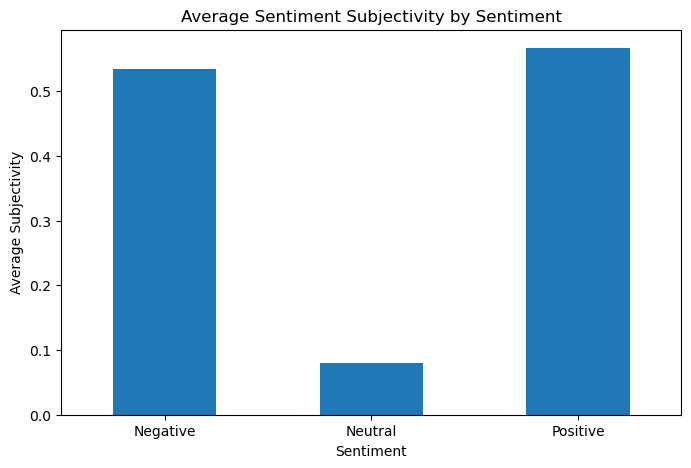

In [70]:
plt.figure(figsize=(8, 5))

sentiment_subjectivity.plot(kind='bar')

plt.title('Average Sentiment Subjectivity by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Subjectivity')
plt.xticks(rotation=0)

plt.show()

### Observation

Positive reviews have the highest average subjectivity at approximately 0.57, followed by Negative reviews at approximately 0.54. Neutral reviews have a much lower subjectivity of approximately 0.08, indicating that neutral reviews contain fewer personal opinions or emotions.

## Top Apps by Number of User Reviews

In [71]:
top_review_apps = reviews['App'].value_counts().head(10)

top_review_apps

App
Angry Birds Classic                                  320
CBS Sports App - Scores, News, Stats & Watch Live    320
Bowmasters                                           320
8 Ball Pool                                          300
Helix Jump                                           300
Calorie Counter - MyFitnessPal                       260
Bubble Shooter                                       260
Garena Free Fire                                     240
DEAD TARGET: FPS Zombie Apocalypse Survival Games    240
Duolingo: Learn Languages Free                       240
Name: count, dtype: int64

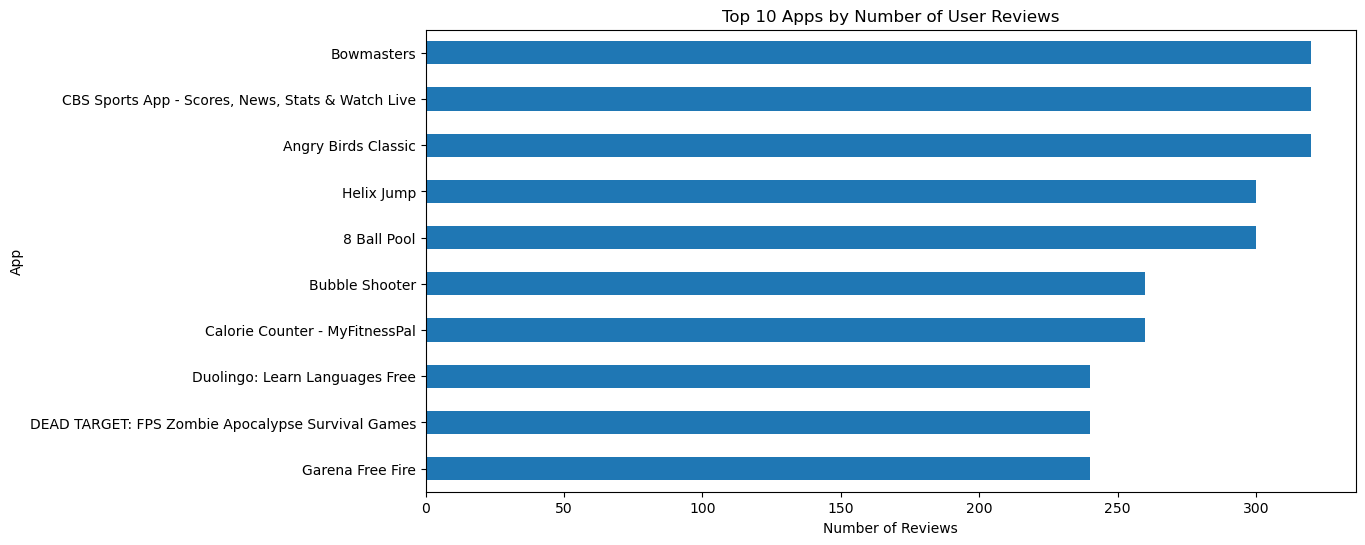

In [72]:
plt.figure(figsize=(12, 6))

top_review_apps.sort_values().plot(kind='barh')

plt.title('Top 10 Apps by Number of User Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('App')

plt.show()

### Observation

The analysis shows that Angry Birds Classic, CBS Sports App, and Bowmasters have the highest number of user reviews, with 320 reviews each. 8 Ball Pool and Helix Jump follow with 300 reviews each. This indicates that these apps have relatively high user engagement in the review dataset.

## Sentiment Distribution by App

In [73]:
sentiment_by_app = pd.crosstab(
    reviews['App'],
    reviews['Sentiment']
)

sentiment_by_app.head(10)

Sentiment,Negative,Neutral,Positive
App,,,
10 Best Foods for You,10,22,162
104 找工作 - 找工作 找打工 找兼職 履歷健檢 履歷診療室,1,8,31
11st,7,10,23
1800 Contacts - Lens Store,6,10,64
1LINE – One Line with One Touch,8,3,27
2018Emoji Keyboard 😂 Emoticons Lite -sticker&gif,1,6,25
21-Day Meditation Experience,10,2,68
"2Date Dating App, Love and matching",7,5,26
2GIS: directory & navigator,6,11,23


In [74]:
top_sentiment_apps = sentiment_by_app.sum(axis=1).sort_values(
    ascending=False
).head(10)

top_sentiment_apps

App
Bowmasters                        312
Helix Jump                        273
Angry Birds Classic               273
Calorie Counter - MyFitnessPal    255
Duolingo: Learn Languages Free    240
Candy Crush Saga                  240
Garena Free Fire                  222
8 Ball Pool                       219
Calorie Counter - Macros          200
10 Best Foods for You             194
dtype: int64

### Observation

The sentiment distribution shows that most apps have more Positive reviews compared with Negative and Neutral reviews. Among the apps analyzed, Bowmasters has the highest total number of user reviews with 312 reviews, followed by Helix Jump and Angry Birds Classic with 273 reviews each. This indicates relatively high user engagement for these apps in the review dataset.

## Positive vs Negative Reviews by Top Apps

In [75]:
top_apps_sentiment = sentiment_by_app.loc[
    top_sentiment_apps.index,
    ['Positive', 'Negative']
]

top_apps_sentiment

Sentiment,Positive,Negative
App,,
Bowmasters,169,119
Helix Jump,209,58
Angry Birds Classic,124,147
Calorie Counter - MyFitnessPal,169,52
Duolingo: Learn Languages Free,200,34
Candy Crush Saga,102,126
Garena Free Fire,136,81
8 Ball Pool,104,106
Calorie Counter - Macros,174,20


### Observation

The comparison shows that most of the top apps have more Positive reviews than Negative reviews. Duolingo, Helix Jump, Calorie Counter - Macros, and 10 Best Foods for You have a clear majority of Positive reviews. However, Angry Birds Classic and Candy Crush Saga have more Negative reviews than Positive reviews. 8 Ball Pool has almost equal numbers of Positive and Negative reviews. Overall, the sentiment varies across apps, showing that user experiences are different for different applications.

# Key Findings

- Family has the highest number of apps.
- The average app rating is approximately 4.20.
- Free apps are much more common than paid apps.
- Most apps have an Everyone content rating.
- Positive reviews are more common than Negative and Neutral reviews.
- Paid apps have a slightly higher average rating than free apps.

# Final Conclusion

The Google Play Store data analysis provided useful insights into app categories, ratings, installations, pricing, content ratings, genres, and user reviews.

The analysis shows that the Family category contains the highest number of apps, followed by Game and Tools. The average app rating is approximately 4.20, indicating generally positive ratings across the dataset.

Free apps are much more common than paid apps, while paid apps have a slightly higher average rating than free apps. Most apps are suitable for Everyone, making this the dominant content-rating group.

The sentiment analysis of user reviews shows that Positive reviews are the most common, followed by Negative and Neutral reviews. Positive reviews also have positive average sentiment polarity, while Negative reviews have negative polarity.

Overall, the analysis shows strong user engagement with popular applications and generally positive user feedback. However, some popular apps also receive a considerable number of negative reviews, indicating opportunities for improving user experience.

# Business Recommendations

1. Focus on highly popular app categories such as Family, Game, and Tools because they contain a large number of applications and represent competitive areas of the Play Store.

2. Monitor negative user reviews regularly to identify common problems and improve application quality and user satisfaction.

3. Analyze highly installed and highly reviewed apps to understand the features and user experiences that contribute to app popularity.

4. Developers of paid applications should maintain high quality because paid apps have a slightly higher average rating than free apps.

5. Use positive user feedback to identify successful features and incorporate similar improvements into future app updates.